# **Algoritmo 4: enfoque neuronal**

En este notebook implementamos el cuarto algoritmo de recomendación, basado
en una red neuronal MLP que aprende a combinar de forma no lineal cuatro
señales heterogéneas: la afinidad topológica del usuario con el autor del
mensaje (vía Personalized PageRank), el perfil semántico del usuario, el
contenido del mensaje candidato (ambos representados con SentenceBERT) y la
similitud psicológica entre usuario y autor (similitud del coseno entre sus
vectores Big Five).

Antes de entrar en la arquitectura neuronal, reconstruimos el contexto que
los tres algoritmos previos dejaron preparado, que es la carga de datos, el grafo
ponderado de entrenamiento, el mapa de embeddings semánticos, el diccionario
de personalidad y la partición temporal 80/20.

## **1. Importación de librerías y configuración del entorno**

Importamos las librerías habituales para manipulación de datos
(`pandas`, `numpy`), grafos (`networkx`), aprendizaje profundo (`torch`) y
NLP (`sentence-transformers`, `scikit-learn`). Configuramos el dispositivo
(GPU si está disponible) y fijamos la semilla en `2908` para garantizar
la reproducibilidad de los resultados.

In [ ]:
# Instalación
!pip install -q sentence-transformers

import os
import math
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# Reproducibilidad: fijamos la semilla en 2908
SEED = 2908
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo: {device}")

Dispositivo activo: cpu


## **2. Carga del conjunto de datos**

Cargamos los cuatro ficheros CSV exportados por el simulador: el censo de
usuarios, el grafo de amistades, el registro de interacciones y el catálogo
de mensajes.

In [ ]:
# messages e interactions son los archivos extendidos

ids = {
    'users':        '1Q00bSqmuaYMaPCC9T3ZWPSssOj8ULQAN',
    'friendships':  '1cZY1aGP-ydnmy14IzU1FVsnx9AhocmN6',
    'interactions': '1ZP2Q1n53lmpQ578nchEZbJn-_fbLhvVS',
    'messages':     '1SYLiH-ySCqRDLTxpuzXgrrxKFoDXupe9'
}

# Los ficheros se cargan en local si están presentes (ejecución offline);
# en caso contrario se descargan desde Google Drive.
import os
def crear_url(file_id):
    return f'https://drive.google.com/uc?export=download&id={file_id}'

def _load_csv(nombre_local, file_id):
    ruta = nombre_local
    src = ruta if os.path.exists(ruta) else crear_url(file_id)
    return pd.read_csv(src, sep=',', quotechar='"', on_bad_lines='warn')

df_users        = _load_csv('users.csv',        ids['users'])
df_friendships  = _load_csv('friendships.csv',  ids['friendships'])
df_interactions = _load_csv('interactions.csv', ids['interactions'])
df_messages     = _load_csv('messages.csv',     ids['messages'])

print(f"Usuarios: {len(df_users)}")
print(f"Amistades: {len(df_friendships)}")
print(f"Interacciones: {len(df_interactions)}")
print(f"Mensajes: {len(df_messages)}")

Usuarios: 220
Amistades: 1450
Interacciones: 2246
Mensajes: 150


### **2.1. Partición temporal y limpieza de strings**

Aplicamos el mismo protocolo de evaluación definido en la metodología:
filtramos usuarios con al menos cuatro interacciones y dividimos el
histórico de cada usuario en un 80% de entrenamiento (cronológicamente más
antiguo) y un 20% de prueba (cronológicamente más reciente). Acto seguido
normalizamos los textos (minúsculas, espacios y caracteres residuales)
para garantizar la coincidencia con el mapa de embeddings.

In [ ]:
# Partición temporal 80/20
df_interactions['created_at'] = pd.to_datetime(df_interactions['created_at'])
df_interactions = df_interactions.sort_values(by=['username', 'created_at'])

min_interactions = 4
user_counts = df_interactions['username'].value_counts()
valid_users = user_counts[user_counts >= min_interactions].index
df_eval = df_interactions[df_interactions['username'].isin(valid_users)].copy()

df_eval['rank']  = df_eval.groupby('username')['created_at'].rank(method='first')
df_eval['total'] = df_eval.groupby('username')['username'].transform('count')
df_eval['is_train'] = df_eval['rank'] <= (df_eval['total'] * 0.8)

df_train = df_eval[df_eval['is_train']].copy().drop(columns=['rank', 'total', 'is_train'])
df_test  = df_eval[~df_eval['is_train']].copy().drop(columns=['rank', 'total', 'is_train'])

# Limpieza de strings para garantizar coincidencia con el embedding_map
for df_ in (df_messages, df_train, df_test):
    col = 'content' if 'content' in df_.columns else 'message_text;'
    df_[col] = df_[col].astype(str).str.strip().str.lower().str.rstrip(';')

print(f"Usuarios evaluables: {len(valid_users)}")
print(f"Train: {len(df_train)} interacciones")
print(f"Test:  {len(df_test)} interacciones")

Usuarios evaluables: 219
Train: 1704 interacciones
Test:  539 interacciones


### **2.2. Construcción del grafo de entrenamiento**

Reconstruimos el grafo ponderado $G_{\text{train}}$ partiendo del sustrato
estático de amistades y reponderando las aristas con las interacciones
exclusivamente del conjunto de entrenamiento. Mantenemos el mismo esquema
de pesos por tipo de interacción que en los algoritmos anteriores
(`read=0.1`, `like=0.2`, `reply=0.4`, `share=0.6`), y los enlaces
implícitos (interacciones con usuarios no seguidos) se añaden con la mitad
del peso.

In [ ]:
# Pesos por tipo de interacción calibrados sobre el inner-val (ver notebook de los
# Algoritmos 1-3). Se mantienen idénticos aquí para coherencia entre todos los modelos.
interaction_weights = {'read': 0.1, 'like': 0.2, 'reply': 0.4, 'share': 0.6}

G_train = nx.DiGraph()
G_train.add_nodes_from(df_users['username'].dropna().unique())

# Capa estática de amistades
base_edges = [
    (row['follower'], row['followed'], 1.0)
    for _, row in df_friendships.iterrows()
    if pd.notna(row['follower']) and pd.notna(row['followed'])
]
G_train.add_weighted_edges_from(base_edges)

# Capa de interacciones (solo train)
df_train['weight_added'] = df_train['interaction_type'].map(interaction_weights).fillna(0)
grouped = df_train.groupby(['username', 'message_author'])['weight_added'].sum().reset_index()

for _, row in grouped.iterrows():
    u, v, w = row['username'], row['message_author'], row['weight_added']
    if pd.isna(u) or pd.isna(v):
        continue
    if G_train.has_edge(u, v):
        G_train[u][v]['weight'] += w
    else:
        G_train.add_edge(u, v, weight=w * 0.5)

print(f"G_train: {G_train.number_of_nodes()} nodos, {G_train.number_of_edges()} aristas")

G_train: 220 nodos, 2100 aristas


### **2.3. Vectorización de personalidad (Big Five adaptado)**

Parseamos la columna `traits` del censo de usuarios y construimos un
diccionario que mapea cada `username` a un vector de cinco dimensiones en
$\{-1, 0, +1\}^5$ correspondiente a Sociability, Friendliness,
Scrupulousness, Neuroticism e Intellectual.

In [ ]:
def parse_traits_to_vector(trait_string):
    if pd.isna(trait_string):
        return np.zeros(5)
    vector = np.zeros(5)
    ts = str(trait_string)
    rasgos = [
        ('Intellectual',    0),
        ('Scrupulousness',  1),
        ('Sociability',     2),
        ('Friendliness',    3),
        ('Neuroticism',     4),
    ]
    for nombre, idx in rasgos:
        if f'{nombre}+' in ts or f'{nombre} +' in ts:
            vector[idx] = 1
        elif f'{nombre}-' in ts or f'{nombre} -' in ts:
            vector[idx] = -1
    return vector

df_users['traits_vector'] = df_users['traits'].apply(parse_traits_to_vector)
personality_dict = dict(zip(df_users['username'], df_users['traits_vector']))
print(f"Vectores de personalidad construidos: {len(personality_dict)}")

Vectores de personalidad construidos: 220


### **2.4. Mapa de embeddings semánticos**

Cargamos el modelo `all-MiniLM-L6-v2` (Sentence-BERT) y pre-calculamos los
embeddings de todos los textos únicos presentes tanto en el histórico de
interacciones como en el catálogo de mensajes. El resultado es un mapa
indexado por texto que permite acceder a cualquier embedding en $O(1)$
durante la inferencia.

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

# Textos únicos en candidatos e histórico
candidate_texts_unique = df_messages['content'].dropna().drop_duplicates().tolist()
history_texts_unique   = df_train['message_text;'].dropna().drop_duplicates().tolist()

print("Calculando embeddings de candidatos...")
candidate_embs = model.encode(candidate_texts_unique, show_progress_bar=True)

print("Calculando embeddings de historial...")
history_embs = model.encode(history_texts_unique, show_progress_bar=True)

embedding_map = {
    **dict(zip(history_texts_unique, history_embs)),
    **dict(zip(candidate_texts_unique, candidate_embs)),
}
print(f"Mapa de embeddings listo: {len(embedding_map)} textos únicos.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Calculando embeddings de candidatos...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Calculando embeddings de historial...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Mapa de embeddings listo: 152 textos únicos.


### **2.5. Funciones de métricas**

Replicamos las tres métricas del marco de evaluación común a todos los
algoritmos del TFM: Recall@10, NDCG@10 y diversidad temática intra-lista.
Para los algoritmos que recomiendan contenido, el `ground truth` son los
textos de los mensajes con los que el usuario interactuó realmente durante
el conjunto de prueba.

In [ ]:
def calculate_recall(recommended_items, true_items, k=10):
    true_set = set(true_items)
    if not true_set:
        return 0.0
    rec_k = recommended_items[:k]
    hits = len(set(rec_k) & true_set)
    return hits / len(true_set)

def calculate_ndcg(recommended_items, true_items, k=10):
    true_set = set(true_items)
    if not true_set:
        return 0.0
    rec_k = recommended_items[:k]
    dcg = sum(1.0 / math.log2(i + 2) for i, item in enumerate(rec_k) if item in true_set)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(true_set), k)))
    return dcg / idcg if idcg > 0 else 0.0

def _get_embeddings_from_map(texts, embedding_map, model):
    result, missing, missing_idx = [], [], []
    for i, t in enumerate(texts):
        if t in embedding_map:
            result.append(embedding_map[t])
        else:
            result.append(None)
            missing.append(t); missing_idx.append(i)
    if missing:
        fresh = model.encode(missing)
        for idx, emb in zip(missing_idx, fresh):
            result[idx] = emb
    return np.array(result)

def calculate_diversity(recommended_texts, model, embedding_map=None):
    if len(recommended_texts) < 2:
        return 0.0
    if embedding_map is not None:
        embeddings = _get_embeddings_from_map(recommended_texts, embedding_map, model)
    else:
        embeddings = model.encode(recommended_texts)
    sim_matrix = cosine_similarity(embeddings)
    sim_values = sim_matrix[np.triu_indices(len(recommended_texts), k=1)]
    return 1.0 - float(np.mean(sim_values))

## **3. Pre-cálculo de señales para el MLP**

La red neuronal recibirá como entrada un vector de 770 dimensiones que
combina cuatro señales: la puntuación topológica del usuario hacia el autor
del mensaje (1 dim), el perfil semántico del usuario (384 dim), el
embedding del mensaje candidato (384 dim) y la similitud psicológica entre
usuario y autor (1 dim).

Para que el bucle de entrenamiento sea computacionalmente viable
pre-calculamos las dos señales más costosas una única vez al inicio:

1. **Personalized PageRank de cada usuario sobre $G_{\text{train}}$.**
   Ejecutar PageRank en cada muestra de entrenamiento sería muy costoso.
   En su lugar lanzamos una llamada por usuario y almacenamos el vector de
   scores completo en un diccionario anidado.

2. **Perfil semántico de cada usuario.** Es la media de los embeddings de
   los mensajes con los que el usuario ha interactuado en el conjunto de
   entrenamiento. Lo almacenamos también en un diccionario para acceso
   $O(1)$ durante el entrenamiento y la inferencia.

### **3.1. Personalized PageRank por usuario**

Para cada usuario válido del conjunto de entrenamiento ejecutamos una vez
el algoritmo Personalized PageRank sobre $G_{\text{train}}$, con la
distribución de personalización concentrada en ese usuario y los pesos de
las aristas como factor de propagación. El resultado es un diccionario
anidado `ppr_per_user[username][author]` que devuelve la afinidad
topológica del usuario hacia cualquier otro nodo de la red en tiempo
constante.

In [ ]:
print("Pre-calculando PPR para cada usuario evaluable...")

ppr_per_user = {}
usuarios_para_ppr = [u for u in valid_users if u in G_train]

for user in tqdm(usuarios_para_ppr):
    personalization = {node: 0.0 for node in G_train.nodes()}
    personalization[user] = 1.0
    ppr_scores = nx.pagerank(G_train, alpha=0.85, personalization=personalization, weight='weight')
    ppr_per_user[user] = ppr_scores

print(f"PPR pre-calculado para {len(ppr_per_user)} usuarios.")

Pre-calculando PPR para cada usuario evaluable...


100%|██████████| 219/219 [00:01<00:00, 204.01it/s]

PPR pre-calculado para 219 usuarios.


### **3.2. Perfil semántico de cada usuario**

El perfil semántico del usuario es la media de los embeddings de los
mensajes con los que interactuó en el conjunto de entrenamiento. Este
vector de 384 dimensiones representa el centroide temático de sus
intereses observados y constituye una de las cuatro señales del MLP.

Si un usuario no tiene histórico en `df_train`, le asignamos un vector de
ceros; estos casos serán muy raros dado el filtro previo de cuatro
interacciones, pero conviene tratarlos defensivamente.

In [ ]:
EMB_DIM = 384  # Dimensión de all-MiniLM-L6-v2

user_profile_emb = {}

for user in valid_users:
    user_history = df_train[df_train['username'] == user]['message_text;'].dropna().tolist()
    if not user_history:
        user_profile_emb[user] = np.zeros(EMB_DIM, dtype=np.float32)
        continue
    history_embeddings = _get_embeddings_from_map(user_history, embedding_map, model)
    user_profile_emb[user] = np.mean(history_embeddings, axis=0).astype(np.float32)

print(f"Perfiles semánticos construidos: {len(user_profile_emb)}")
print(f"Dimensión de cada perfil: {next(iter(user_profile_emb.values())).shape}")

Perfiles semánticos construidos: 219
Dimensión de cada perfil: (384,)


### **3.3. Función de construcción del vector de entrada**

Definimos la función `build_feature_vector(user, message_content,
message_author)`, que concatena las cuatro señales en el orden establecido:

$$
\mathbf{x} = \big[\, \underbrace{s_{\text{PPR}}}_{1} \;\big|\;
\underbrace{\mathbf{e}_{\text{user}}}_{384} \;\big|\;
\underbrace{\mathbf{e}_{\text{msg}}}_{384} \;\big|\;
\underbrace{s_{\text{pers}}}_{1} \,\big] \in \mathbb{R}^{770}
$$

La función accede a las estructuras pre-calculadas y, ante valores
faltantes (usuarios sin PPR, autores sin entrada en el diccionario de
personalidad, textos sin embedding), devuelve valores neutros (0 para
scores, vectores de ceros para embeddings) para no romper el pipeline.

In [ ]:
def build_feature_vector(user, message_content, message_author):
    """
    Construye el vector de 770 dimensiones que alimentará al MLP.
    Orden: [ PPR(1) | perfil_usuario(384) | embedding_mensaje(384) | personalidad(1) ]
    """
    # 1. Señal topológica (PPR)
    ppr_score = 0.0
    if user in ppr_per_user and message_author in ppr_per_user[user]:
        ppr_score = ppr_per_user[user][message_author]

    # 2. Perfil semántico del usuario
    user_emb = user_profile_emb.get(user, np.zeros(EMB_DIM, dtype=np.float32))

    # 3. Embedding del mensaje candidato
    if message_content in embedding_map:
        msg_emb = embedding_map[message_content]
    else:
        msg_emb = model.encode([message_content])[0]
    msg_emb = msg_emb.astype(np.float32)

    # 4. Similitud de personalidad (coseno normalizado a [0, 1])
    target_pers = personality_dict.get(user,           np.zeros(5)).reshape(1, -1)
    author_pers = personality_dict.get(message_author, np.zeros(5)).reshape(1, -1)
    pers_sim = (cosine_similarity(target_pers, author_pers)[0][0] + 1) / 2

    return np.concatenate([
        np.array([ppr_score], dtype=np.float32),
        user_emb,
        msg_emb,
        np.array([pers_sim], dtype=np.float32),
    ])


# Verificación
sample_user   = list(valid_users)[0]
sample_row    = df_messages.iloc[0]
sample_vec    = build_feature_vector(sample_user, sample_row['content'], sample_row['sender_username'])
print(f"Vector de entrada construido. Shape: {sample_vec.shape}")
assert sample_vec.shape == (770,), "El vector no tiene 770 dimensiones."
print("Verificación correcta: 770 dimensiones.")

Vector de entrada construido. Shape: (770,)
Verificación correcta: 770 dimensiones.


## **4. Sub-split temporal del conjunto de entrenamiento**

El Algoritmo 4 requiere de un
conjunto interno de validación para optimizar hiperparámetros y aplicar
`early stopping`. Este sub-split también es temporal: por cada usuario, el
80% más antiguo de sus interacciones en `df_train` queda como `df_train_nn`
y el 20% más reciente como `df_val_nn`.

De esta forma garantizamos que el modelo nunca tenga acceso a información
del futuro durante el entrenamiento, ni siquiera dentro del propio conjunto
de entrenamiento original. El 80%/20% nominal no se cumple de forma exacta
por usuario, ya que con pocas interacciones por agente el corte temporal
deja proporciones desiguales (un usuario con cuatro interacciones queda
3/1, uno con tres en 2/1). La celda siguiente imprime las proporciones
globales reales resultantes (`train_nn` / `val_nn` / `test`).

In [ ]:
# Sub-split temporal por usuario dentro de df_train
df_train_sorted = df_train.sort_values(by=['username', 'created_at']).copy()
df_train_sorted['rank']  = df_train_sorted.groupby('username')['created_at'].rank(method='first')
df_train_sorted['total'] = df_train_sorted.groupby('username')['username'].transform('count')
df_train_sorted['is_inner_train'] = df_train_sorted['rank'] <= (df_train_sorted['total'] * 0.8)

df_train_nn = df_train_sorted[ df_train_sorted['is_inner_train']].copy().drop(columns=['rank', 'total', 'is_inner_train'])
df_val_nn   = df_train_sorted[~df_train_sorted['is_inner_train']].copy().drop(columns=['rank', 'total', 'is_inner_train'])

print(f"Train_nn (entrenamiento interno):  {len(df_train_nn)} interacciones")
print(f"Val_nn   (validación interna):     {len(df_val_nn)} interacciones")
print(f"Test     (oculto, reservado):      {len(df_test)} interacciones")

# Proporciones globales reales (para reportarlas con exactitud en la memoria)
_tot = len(df_train_nn) + len(df_val_nn) + len(df_test)
print(f"Proporciones globales -> train_nn: {len(df_train_nn)/_tot*100:.0f}% | "
      f"val_nn: {len(df_val_nn)/_tot*100:.0f}% | test: {len(df_test)/_tot*100:.0f}%")

Train_nn (entrenamiento interno):  1284 interacciones
Val_nn   (validación interna):     420 interacciones
Test     (oculto, reservado):      539 interacciones
Proporciones globales -> train_nn: 57% | val_nn: 19% | test: 24%


## **5. Generación de muestras positivas y negativas**

A diferencia de los modelos topológicos y semánticos, una red neuronal
necesita aprender no solo qué es relevante para el usuario, sino también
qué no lo es. Como el registro original solo contiene interacciones
exitosas (todas son positivas implícitas), generamos muestras negativas
mediante un muestreo aleatorio de mensajes con los que el usuario no
interactuó.

Adoptamos un ratio negativo de 1:2 (dos negativas por cada positiva), un
punto equilibrado entre cantidad de datos y balance de clases adecuado para el
tamaño reducido del conjunto de entrenamiento. Cada muestra queda
representada como un triplete `(username, message_content,
message_author, label)`, donde `label = 1` para positivas y `label = 0`
para negativas.

In [ ]:
NEGATIVE_RATIO = 2  # Dos negativas por cada positiva
rng = random.Random(SEED)

def generate_samples(df_split, df_messages_pool, negative_ratio=2):
    """
    Construye muestras positivas y negativas a partir de un dataframe de interacciones.
    Devuelve una lista de tuplas (username, message_content, message_author, label).
    """
    # Diccionario: usuario -> conjunto de textos con los que YA interactuó (positivas)
    user_to_texts = df_split.groupby('username')['message_text;'].apply(set).to_dict()

    # Catálogo global de mensajes candidatos (content, author)
    all_messages = list(zip(df_messages_pool['content'], df_messages_pool['sender_username']))

    samples = []

    # POSITIVAS
    for _, row in df_split.iterrows():
        user   = row['username']
        text   = row['message_text;']
        author = row['message_author']
        if pd.isna(user) or pd.isna(text) or pd.isna(author):
            continue
        samples.append((user, text, author, 1))

    # NEGATIVAS
    positives_count = sum(1 for s in samples if s[3] == 1)
    target_negatives = positives_count * negative_ratio
    negatives_generated = 0
    intentos_max = target_negatives * 20  # Para evitar bucles infinitos
    intentos = 0

    while negatives_generated < target_negatives and intentos < intentos_max:
        intentos += 1
        user = rng.choice(list(user_to_texts.keys()))
        msg_text, msg_author = rng.choice(all_messages)
        # Solo es válida si el usuario no ha interactuado con ese texto
        if msg_text not in user_to_texts.get(user, set()) and msg_author != user:
            samples.append((user, msg_text, msg_author, 0))
            negatives_generated += 1

    return samples

train_samples = generate_samples(df_train_nn, df_messages, negative_ratio=NEGATIVE_RATIO)
val_samples   = generate_samples(df_val_nn,   df_messages, negative_ratio=NEGATIVE_RATIO)

n_train_pos = sum(1 for s in train_samples if s[3] == 1)
n_train_neg = sum(1 for s in train_samples if s[3] == 0)
n_val_pos   = sum(1 for s in val_samples   if s[3] == 1)
n_val_neg   = sum(1 for s in val_samples   if s[3] == 0)

print(f"Train_nn: {len(train_samples)} muestras ({n_train_pos} positivas + {n_train_neg} negativas)")
print(f"Val_nn:   {len(val_samples)} muestras ({n_val_pos} positivas + {n_val_neg} negativas)")

Train_nn: 3852 muestras (1284 positivas + 2568 negativas)
Val_nn:   1260 muestras (420 positivas + 840 negativas)


## **6. Dataset y DataLoader**

Definimos la clase `HybridDataset`, que envuelve la lista de muestras y
las transforma en tensores de PyTorch usando la función
`build_feature_vector` definida antes. Cada elemento devuelto por
`__getitem__` es una pareja `(vector_770, label)` lista para entrar al
modelo.

Construimos un `DataLoader` para entrenamiento (con `shuffle=True` para
mezclar muestras positivas y negativas dentro de cada batch) y otro para
validación (sin shuffle, para que las curvas de pérdida sean
reproducibles).

In [ ]:
class HybridDataset(Dataset):
    """
    Dataset que envuelve muestras (user, message_content, message_author, label)
    y las transforma al vuelo en tensores de 770 dimensiones.
    """
    def __init__(self, samples, feature_builder):
        self.samples = samples
        self.feature_builder = feature_builder

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user, text, author, label = self.samples[idx]
        x = self.feature_builder(user, text, author)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


BATCH_SIZE = 64

train_dataset = HybridDataset(train_samples, build_feature_vector)
val_dataset   = HybridDataset(val_samples,   build_feature_vector)

# Generador con semilla para que el shuffle sea reproducible
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader: {len(train_loader)} batches de hasta {BATCH_SIZE} muestras")
print(f"Val   DataLoader: {len(val_loader)} batches")

# Verificación rápida de un batch
x_batch, y_batch = next(iter(train_loader))
print(f"\nForma de un batch -> X: {x_batch.shape}, Y: {y_batch.shape}")
print(f"Distribución de labels en el primer batch: {y_batch.tolist().count(1.0)} positivas, {y_batch.tolist().count(0.0)} negativas")

Train DataLoader: 61 batches de hasta 64 muestras
Val   DataLoader: 20 batches

Forma de un batch -> X: torch.Size([64, 770]), Y: torch.Size([64])
Distribución de labels en el primer batch: 23 positivas, 41 negativas


## **7. Arquitectura de la red neuronal**

Definimos la clase `HybridRecommenderNN`, un perceptrón multicapa que
recibe el vector concatenado de 770 dimensiones y produce una puntuación
escalar interpretable como probabilidad de interacción (tras aplicar la
sigmoide implícita en `BCEWithLogitsLoss`).

La arquitectura creada busca contrarrestar el riesgo
de sobreajuste en el contexto de datos escasos en el que operamos:

- Capa de entrada: $770 \to 128$, seguida de `BatchNorm1d` y `ReLU`.
- Capa oculta: $128 \to 32$, seguida de `BatchNorm1d` y `ReLU`.
- Capa de salida: $32 \to 1$, sin activación final (la sigmoide la
  aplica la función de pérdida).
- Regularización: `Dropout` tras cada capa oculta (valor inicial $p=0.4$; el
  valor definitivo $p=0.5$ se fija tras la búsqueda de hiperparámetros).

El uso de `BatchNorm` antes de la activación estabiliza las distribuciones
internas de cada capa, y el dropout fuerza al modelo a no
depender de neuronas concretas, mejorando la generalización.

In [ ]:
class HybridRecommenderNN(nn.Module):
    """
    MLP que recibe un vector de 770 dimensiones (PPR + perfil usuario + mensaje + personalidad)
    y devuelve un logit por muestra. La sigmoide está implícita en BCEWithLogitsLoss.
    """
    def __init__(self, input_dim=770, hidden_dims=(128, 32), dropout_rate=0.4):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.bn1 = nn.BatchNorm1d(hidden_dims[0])

        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.bn2 = nn.BatchNorm1d(hidden_dims[1])

        self.output  = nn.Linear(hidden_dims[1], 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.output(x)
        return x.squeeze(-1)  # (batch, 1) -> (batch,)


# Instanciamos y mostramos un resumen
modelo_nn = HybridRecommenderNN(input_dim=770, hidden_dims=(128, 32), dropout_rate=0.4).to(device)
print(modelo_nn)

# Conteo de parámetros entrenables
n_params = sum(p.numel() for p in modelo_nn.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {n_params:,}")

HybridRecommenderNN(
  (fc1): Linear(in_features=770, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)

Parámetros entrenables: 103,169


## **8. Bucle de entrenamiento con `early stopping`**

Definimos la función `train_model`, que entrena el modelo durante un
número máximo de épocas evaluando la pérdida en el conjunto de validación
al final de cada una. Si la pérdida de validación no mejora durante
`patience` épocas consecutivas, detenemos el entrenamiento y restauramos
los pesos del mejor modelo observado.

Componentes principales:

- **Optimizador**: Adam con `weight_decay` para regularización L2 sobre
  los parámetros, complementaria al dropout.

- **Función de pérdida**: `BCEWithLogitsLoss`, que combina la sigmoide y
  la entropía cruzada binaria en una única operación numéricamente estable.
  
- **Early stopping**: monitoreo de la pérdida de validación, con
  restauración del mejor estado de pesos al finalizar.

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    device=device,
    verbose=True,
):
    """
    Entrena el modelo con early stopping basado en la pérdida de validación.
    Devuelve el modelo entrenado con los pesos de la mejor época, y las curvas
    de pérdida de train y val.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    train_losses, val_losses = [], []
    best_val_loss   = float('inf')
    best_state      = None
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        # === ENTRENAMIENTO ===
        model.train()
        total_train = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_train += loss.item() * x.size(0)
        avg_train = total_train / len(train_loader.dataset)
        train_losses.append(avg_train)

        # === VALIDACIÓN ===
        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                total_val += loss.item() * x.size(0)
        avg_val = total_val / len(val_loader.dataset)
        val_losses.append(avg_val)

        if verbose:
            print(f"Época {epoch:2d} | Train loss: {avg_train:.4f} | Val loss: {avg_val:.4f}")

        # === EARLY STOPPING ===
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"\nEarly stopping en época {epoch} (sin mejora durante {patience} épocas).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        if verbose:
            print(f"Mejor val loss alcanzada: {best_val_loss:.4f}")

    return model, train_losses, val_losses

## **9. Entrenamiento inicial del modelo**

Lanzamos un primer entrenamiento con la configuración por defecto
(`lr=1e-3`, `weight_decay=1e-4`, `patience=8`, hasta 50 épocas) para
validar que la arquitectura aprende y que el early stopping converge.
Este entrenamiento sirve como punto de partida.

In [ ]:
# Reinstanciar el modelo para arrancar con pesos limpios
modelo_nn = HybridRecommenderNN(input_dim=770, hidden_dims=(128, 32), dropout_rate=0.4)

modelo_nn, train_losses, val_losses = train_model(
    modelo_nn,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=8,
    device=device,
    verbose=True,
)

Época  1 | Train loss: 0.6310 | Val loss: 0.6277
Época  2 | Train loss: 0.4976 | Val loss: 0.5879
Época  3 | Train loss: 0.4289 | Val loss: 0.5981
Época  4 | Train loss: 0.3868 | Val loss: 0.5685
Época  5 | Train loss: 0.3426 | Val loss: 0.5786
Época  6 | Train loss: 0.3189 | Val loss: 0.5617
Época  7 | Train loss: 0.2856 | Val loss: 0.5504
Época  8 | Train loss: 0.2652 | Val loss: 0.5213
Época  9 | Train loss: 0.2564 | Val loss: 0.5569
Época 10 | Train loss: 0.2431 | Val loss: 0.5589
Época 11 | Train loss: 0.2244 | Val loss: 0.5527
Época 12 | Train loss: 0.2113 | Val loss: 0.5565
Época 13 | Train loss: 0.1989 | Val loss: 0.6067
Época 14 | Train loss: 0.2027 | Val loss: 0.5502
Época 15 | Train loss: 0.1901 | Val loss: 0.5780
Época 16 | Train loss: 0.1787 | Val loss: 0.5975

Early stopping en época 16 (sin mejora durante 8 épocas).
Mejor val loss alcanzada: 0.5213




Representamos la evolución de la pérdida en entrenamiento y validación
a lo largo de las épocas. La separación entre ambas curvas nos da una
primera indicación visual del nivel de sobreajuste del modelo: la
pérdida de entrenamiento sigue cayendo mientras la de validación se
estanca e incluso sube, por lo que el modelo está memorizando el conjunto de entrenamiento.

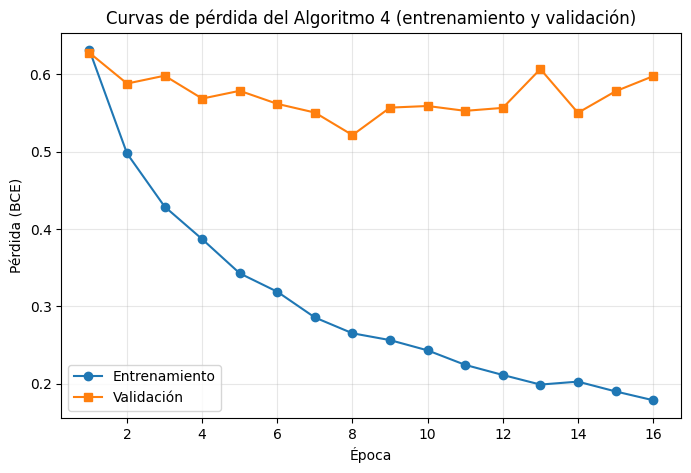

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Entrenamiento', marker='o')
plt.plot(range(1, len(val_losses) + 1),   val_losses,   label='Validación',    marker='s')
plt.xlabel('Época')
plt.ylabel('Pérdida (BCE)')
plt.title('Curvas de pérdida del Algoritmo 4 (entrenamiento y validación)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Estas observaciones corresponden al **primer entrenamiento de referencia**
(configuración inicial, antes de la búsqueda de hiperparámetros), no al
modelo definitivo:

- La pérdida de entrenamiento cae de forma sostenida mientras la de
  validación se estanca y oscila tras unas pocas épocas.
- La brecha creciente entre ambas curvas es la firma clásica del
  sobreajuste, esperable dado que el número de parámetros del modelo es de
  un orden de magnitud muy superior al de muestras de entrenamiento.

Las curvas del modelo **definitivo** (con la configuración ganadora del
grid search) se muestran más adelante y son las que se reportan en la
memoria como Figura 3.2.

## **10. Inferencia Top-K sobre el conjunto de candidatos**

Una vez entrenado el modelo, lo aplicamos en modo inferencia para
producir las listas de recomendaciones que después evaluaremos. Para cada
usuario del conjunto de prueba, la función `get_neural_recommendations`
sigue este procedimiento:

1. Filtra del catálogo de mensajes aquellos textos con los que el usuario
   ya interactuó en `df_train`, evitando recomendar contenido ya consumido.
2. Construye un tensor de tamaño `(n_candidatos, 770)` con todos los
   vectores de características de los candidatos restantes.
3. Pasa el tensor al modelo en una única operación por lotes (mucho más
   eficiente que iterar mensaje a mensaje) y obtiene un score por candidato.
4. Ordena los scores y devuelve los `top_k` mensajes con mayor puntuación.

In [ ]:
@torch.no_grad()
def get_neural_recommendations(target_user, df_interactions, df_messages, model,
                               feature_builder, top_k=10, device=device):
    """
    Devuelve los top_k mensajes recomendados para target_user usando el modelo entrenado.
    Mantiene la misma firma de salida que get_semantic_recommendations y
    get_hybrid_recommendations para que la evaluación sea coherente.
    """
    # Histórico del usuario para filtrar candidatos ya consumidos
    user_history = df_interactions[df_interactions['username'] == target_user]['message_text;'].dropna().tolist()
    history_set  = set(user_history)

    candidates_df = df_messages[
        ~df_messages['content'].isin(history_set) &
        (df_messages['sender_username'] != target_user)
    ].drop_duplicates('content').copy()


    if candidates_df.empty:
        return []

    # Construir matriz (n_candidatos, 770) de una vez
    feature_matrix = np.stack([
        feature_builder(target_user, row['content'], row['sender_username'])
        for _, row in candidates_df.iterrows()
    ])
    x_tensor = torch.tensor(feature_matrix, dtype=torch.float32).to(device)

    # Inferencia por lotes
    model.eval()
    logits = model(x_tensor)
    scores = torch.sigmoid(logits).cpu().numpy()  # probabilidades en [0, 1]

    # Ranking
    candidates_df['neural_score'] = scores
    top_candidates = candidates_df.sort_values('neural_score', ascending=False).head(top_k)

    return [
        {'author': row['sender_username'], 'content': row['content'], 'score': float(row['neural_score'])}
        for _, row in top_candidates.iterrows()
    ]

# Prueba rápida con un usuario aleatorio
sample_user = rng.choice(list(valid_users))
recs_sample = get_neural_recommendations(sample_user, df_train, df_messages,
                                         modelo_nn, build_feature_vector, top_k=5)
print(f"\nRecomendaciones neuronales para {sample_user}:")
for rank, rec in enumerate(recs_sample, 1):
    preview = rec['content'][:80] + ('...' if len(rec['content']) > 80 else '')
    print(f"  {rank}. [score={rec['score']:.3f}] {rec['author']}: {preview}")


Recomendaciones neuronales para cha6466_ods_7450e0:
  1. [score=0.890] ab6b03_wbeory_ab6b03: man, the ukraine situation is just wild. so much going on, hard to even keep up....
  2. [score=0.788] joseph_b72ff6_341: set up the telescope last night, showed my niece saturn for the first time. she ...
  3. [score=0.521] margaret_idr872_176010884: trucking across the country, you see so many cultures. it's beautiful how unique...
  4. [score=0.517] john_28ab89_850: another cross-country haul. usa's a big place alright, but man, these roads are ...
  5. [score=0.505] moniquez42_c861bf: everyone talks about 'culture' like it's one thing, but they only show you what ...


## **11. Evaluación offline del modelo sobre `df_test`**

Iteramos sobre los usuarios del conjunto de prueba y, para cada uno,
generamos su lista de Top-10 con el modelo entrenado y la comparamos
contra el `ground truth` (los textos de los mensajes con los que el
usuario interactuó realmente en el conjunto de prueba). Calculamos las
tres métricas del marco común del TFM:

- **Recall@10**: fracción de mensajes relevantes recuperados.
- **NDCG@10**: calidad del ordenamiento de la lista.
- **Diversidad temática**: distancia semántica intra-lista.

Solo se evalúan los usuarios con al menos un mensaje en el `ground truth`,
para no contaminar las medias con casos donde el cálculo no tiene sentido.

In [ ]:
usuarios_test = df_test['username'].unique()

resultados_alg4 = {'recall': [], 'ndcg': [], 'diversity': []}

print(f"Evaluando Algoritmo 4 sobre {len(usuarios_test)} usuarios...")

for user in tqdm(usuarios_test):
    true_texts = (df_test[df_test['username'] == user]['message_text;']
                          .dropna()
                          .drop_duplicates()
                          .tolist())
    if not true_texts:
        continue

    recs = get_neural_recommendations(user, df_train, df_messages,
                                      modelo_nn, build_feature_vector, top_k=10)
    if not recs:
        continue

    rec_texts = [rec['content'] for rec in recs]
    resultados_alg4['recall'].append(   calculate_recall(rec_texts, true_texts, k=10))
    resultados_alg4['ndcg'].append(     calculate_ndcg(rec_texts,   true_texts, k=10))
    resultados_alg4['diversity'].append(calculate_diversity(rec_texts, model, embedding_map=embedding_map))

# Resultados promedio
print("\n" + "="*60)
print("  RESULTADOS DEL ALGORITMO 4 (red neuronal, baseline)")
print("="*60)
print(f"  - Recall@10:           {np.mean(resultados_alg4['recall']):.4f}")
print(f"  - NDCG@10:             {np.mean(resultados_alg4['ndcg']):.4f}")
print(f"  - Diversidad temática: {np.mean(resultados_alg4['diversity']):.4f}")
print(f"  - Usuarios evaluados:  {len(resultados_alg4['recall'])}")

Evaluando Algoritmo 4 sobre 219 usuarios...


100%|██████████| 219/219 [00:16<00:00, 13.58it/s]


  RESULTADOS DEL ALGORITMO 4 (red neuronal, baseline)
  - Recall@10:           0.1111
  - NDCG@10:             0.0768
  - Diversidad temática: 0.8429
  - Usuarios evaluados:  219


Estas métricas se corresponden al modelo de baseline,
entrenado con hiperparámetros por defecto y con un nivel de sobreajuste
alto. Por tanto no representan el rendimiento óptimo del Algoritmo 4
sino el del primer entrenamiento. En la siguiente sección lanzamos una
búsqueda sobre los hiperparámetros más sensibles al overfitting (capacidad
del modelo, intensidad del dropout, regularización L2 y tasa de
aprendizaje) con el objetivo de mejorar tanto la precisión como la brecha
entre las curvas de pérdida.

## **12. Búsqueda de hiperparámetros**


El entrenamiento del modelo de referencia muestra sobreajuste y un NDCG@10
notablemente más bajo que el Recall@10, lo que revela una capacidad
efectiva mal calibrada para los datos de los que que disponemos.
Lanzamos por ello una búsqueda sistemática sobre los hiperparámetros más
sensibles: `hidden_dims`, `dropout_rate`, `weight_decay`, `lr` y
`batch_size`.

Una particularidad del régimen de datos escasos es que el entrenamiento
exhibe una alta varianza estocástica entre ejecuciones: una misma
configuración puede arrojar métricas distintas según el orden de los
batches, la inicialización de pesos o el dropout. Por eso el grid search
se estructura en dos fases: una **exploratoria** con un único
entrenamiento por configuración, que acota la zona prometedora del
espacio; y una **fase multi-seed** que reentrena las configuraciones
finalistas con cinco semillas distintas y reporta el NDCG@10 como
media ± desviación estándar. El criterio de selección es el NDCG@10
sobre `val_nn`, ya que es la métrica que mejor refleja la calidad del
ordenamiento. El conjunto `df_test` permanece oculto durante toda la
búsqueda.



Definimos una función auxiliar que evalúa un modelo entrenado sobre el
ground truth de `val_nn` (los textos de las interacciones del 20% más
reciente de `df_train`) y devuelve el NDCG@10 promedio. Es la misma
lógica que la evaluación final, pero apuntando al conjunto de validación
en lugar de al conjunto de prueba.

In [ ]:
def evaluate_ndcg_on_val(model, df_inner_train, df_val_inner, df_messages,
                        feature_builder, top_k=10):
    """
    Devuelve el NDCG@10 promedio del modelo sobre el conjunto de validación interna.
    df_inner_train se pasa para filtrar los candidatos ya consumidos por el usuario.
    """
    usuarios_val = df_val_inner['username'].unique()
    ndcgs = []

    for user in usuarios_val:
        true_texts = (df_val_inner[df_val_inner['username'] == user]['message_text;']
                                    .dropna()
                                    .drop_duplicates()
                                    .tolist())
        if not true_texts:
            continue

        recs = get_neural_recommendations(user, df_inner_train, df_messages,
                                          model, feature_builder, top_k=top_k)
        if not recs:
            continue

        rec_texts = [rec['content'] for rec in recs]
        ndcgs.append(calculate_ndcg(rec_texts, true_texts, k=top_k))

    return float(np.mean(ndcgs)) if ndcgs else 0.0



Cubrimos un grid moderado de doce combinaciones, suficiente para acotar
la zona prometedora del espacio sin hacer la búsqueda inviable. En esta
fase cada configuración se entrena una sola vez, ya que el
objetivo es localizar la región prometedora, no identificar el óptimo
puntual.

In [ ]:
from itertools import product

param_grid = {
    'hidden_dims':   [(64, 16), (128, 32), (256, 64)],
    'dropout_rate':  [0.3, 0.5],
    'weight_decay':  [1e-4, 1e-3],
    'lr':            [1e-3],          # Fijo de momento
    'batch_size':    [64],            # Fijo de momento
}

# Generamos todas las combinaciones cartesianas
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]
print(f"Se evaluarán {len(combinations)} combinaciones de hiperparámetros.")

Se evaluarán 12 combinaciones de hiperparámetros.


### **12.1. Ejecución del primer grid**



Iteramos sobre todas las combinaciones, entrenando un modelo nuevo para
cada una con early stopping y evaluando el NDCG@10 sobre `val_nn`. Para
ahorrar tiempo de cómputo, fijamos `epochs=40` y `patience=6`, suficiente
para que la mayoría de configuraciones converjan sin alargar la búsqueda
innecesariamente. Al final imprimimos un ranking ordenado por NDCG.

In [ ]:
EPOCHS_GS  = 40
PATIENCE_GS = 6

resultados_grid = []

print(f"Lanzando grid search con {len(combinations)} configuraciones...\n")

for i, cfg in enumerate(combinations, 1):
    print(f"[{i}/{len(combinations)}] cfg = {cfg}")

    # Reinstanciar el modelo con la configuración
    modelo_cfg = HybridRecommenderNN(
        input_dim=770,
        hidden_dims=cfg['hidden_dims'],
        dropout_rate=cfg['dropout_rate'],
    )

    # Reconstruir los loaders con el batch_size de la cfg (si difiere)
    g_cfg = torch.Generator(); g_cfg.manual_seed(SEED)
    tl = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True,  generator=g_cfg)
    vl = DataLoader(val_dataset,   batch_size=cfg['batch_size'], shuffle=False)

    # Entrenar (silencioso para no inundar la salida)
    modelo_cfg, tr_losses, va_losses = train_model(
        modelo_cfg, tl, vl,
        epochs=EPOCHS_GS, lr=cfg['lr'], weight_decay=cfg['weight_decay'],
        patience=PATIENCE_GS, device=device, verbose=False,
    )

    # Evaluar NDCG@10 sobre val_nn
    ndcg_val = evaluate_ndcg_on_val(modelo_cfg, df_train_nn, df_val_nn,
                                    df_messages, build_feature_vector, top_k=10)

    resultados_grid.append({
        'cfg': cfg,
        'ndcg_val': ndcg_val,
        'best_train_loss': min(tr_losses),
        'best_val_loss':   min(va_losses),
        'epochs_run':      len(tr_losses),
        'gap': min(va_losses) - min(tr_losses),
    })
    print(f"    -> NDCG@10 val: {ndcg_val:.4f} | best val loss: {min(va_losses):.4f} | gap: {min(va_losses) - min(tr_losses):.4f}\n")

# Ranking por NDCG descendente
resultados_grid.sort(key=lambda r: r['ndcg_val'], reverse=True)

print("="*70)
print("  RANKING DE CONFIGURACIONES (por NDCG@10 sobre val_nn)")
print("="*70)
for rank, r in enumerate(resultados_grid[:5], 1):
    print(f"\n#{rank}  NDCG@10 = {r['ndcg_val']:.4f}  (gap={r['gap']:.3f}, épocas={r['epochs_run']})")
    print(f"     hidden_dims={r['cfg']['hidden_dims']}, dropout={r['cfg']['dropout_rate']}, "
          f"weight_decay={r['cfg']['weight_decay']}, lr={r['cfg']['lr']}, batch={r['cfg']['batch_size']}")

Lanzando grid search con 12 configuraciones...

[1/12] cfg = {'hidden_dims': (64, 16), 'dropout_rate': 0.3, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 64}
    -> NDCG@10 val: 0.2442 | best val loss: 0.5354 | gap: 0.3645

[2/12] cfg = {'hidden_dims': (64, 16), 'dropout_rate': 0.3, 'weight_decay': 0.001, 'lr': 0.001, 'batch_size': 64}
    -> NDCG@10 val: 0.2972 | best val loss: 0.5309 | gap: 0.3630

[3/12] cfg = {'hidden_dims': (64, 16), 'dropout_rate': 0.5, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 64}
    -> NDCG@10 val: 0.1832 | best val loss: 0.5317 | gap: 0.2727

[4/12] cfg = {'hidden_dims': (64, 16), 'dropout_rate': 0.5, 'weight_decay': 0.001, 'lr': 0.001, 'batch_size': 64}
    -> NDCG@10 val: 0.2243 | best val loss: 0.5200 | gap: 0.2710

[5/12] cfg = {'hidden_dims': (128, 32), 'dropout_rate': 0.3, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 64}
    -> NDCG@10 val: 0.1870 | best val loss: 0.5123 | gap: 0.3265

[6/12] cfg = {'hidden_dims': (128, 32), 'dropout

La búsqueda explora doce configuraciones cruzando tres opciones de
capacidad ($\texttt{hidden\_dims} \in \{(64,16), (128,32), (256,64)\}$),
dos de dropout ($\{0.3, 0.5\}$) y dos de regularización L2
($\texttt{weight\_decay} \in \{10^{-4}, 10^{-3}\}$), manteniendo fija la
tasa de aprendizaje ($10^{-3}$) y el tamaño de lote ($64$). El criterio de
selección es el NDCG@10 sobre el conjunto de validación interna
$\texttt{val\_nn}$. No variamos el tamaño de lote por el reducido volumen
de datos: valores menores hacen poco fiables las estadísticas de
`BatchNorm1d` y valores mayores dejan muy pocas actualizaciones de
gradiente por época.

En este régimen de datos escasos, un único entrenamiento por configuración
es una observación demasiado ruidosa. Una misma configuración arroja
métricas distintas según la inicialización de pesos, el orden de los
batches o el dropout. Por eso esta fase es solo **exploratoria** (acota la
región prometedora del espacio) y la decisión final se toma en la fase
multi-seed que sigue, reentrenando las configuraciones finalistas con
varias semillas. El conjunto $\texttt{df\_test}$ permanece oculto durante
toda la búsqueda.

### **12.2. Validación con múltiples semillas**

Las primeras posiciones del ranking global se separan por menos de
0.04 puntos en NDCG@10, una magnitud comparable a la varianza esperada
entre ejecuciones de una misma configuración. Para distinguir mejoras
reales de ruido, reentrenamos las tres configuraciones más prometedoras
con cinco semillas distintas (2908, 42, 0, 123, 777) y reportamos el
NDCG@10 como media ± desviación estándar.

In [ ]:
def set_all_seeds(seed):
    """Fija todas las fuentes de aleatoriedad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_and_evaluate_with_seed(cfg, seed):
    """Entrena un modelo con la configuración y semilla dadas, y devuelve NDCG@10 sobre val_nn."""
    set_all_seeds(seed)

    modelo_cfg = HybridRecommenderNN(
        input_dim=770,
        hidden_dims=cfg['hidden_dims'],
        dropout_rate=cfg['dropout_rate'],
    )

    g_seed = torch.Generator(); g_seed.manual_seed(seed)
    tl = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True,  generator=g_seed)
    vl = DataLoader(val_dataset,   batch_size=cfg['batch_size'], shuffle=False)

    modelo_cfg, tr_losses, va_losses = train_model(
        modelo_cfg, tl, vl,
        epochs=EPOCHS_GS, lr=cfg['lr'], weight_decay=cfg['weight_decay'],
        patience=PATIENCE_GS, device=device, verbose=False,
    )

    ndcg_val = evaluate_ndcg_on_val(modelo_cfg, df_train_nn, df_val_nn,
                                    df_messages, build_feature_vector, top_k=10)
    return ndcg_val, min(va_losses), min(tr_losses)


# Configuraciones candidatas
candidatas = [
    {'hidden_dims': (64, 16), 'dropout_rate': 0.3, 'weight_decay': 1e-3, 'lr': 1e-3, 'batch_size': 64},
    {'hidden_dims': (128, 32), 'dropout_rate': 0.5, 'weight_decay': 1e-4, 'lr': 1e-3, 'batch_size': 64},
    {'hidden_dims': (128, 32), 'dropout_rate': 0.5, 'weight_decay': 1e-3, 'lr': 1e-3, 'batch_size': 64},
]

SEEDS_MULTISEED = [2908, 42, 0, 123, 777]
resultados_multiseed = []

print(f"Multi-seed: {len(candidatas)} configuraciones × {len(SEEDS_MULTISEED)} semillas = {len(candidatas)*len(SEEDS_MULTISEED)} entrenamientos\n")

for i, cfg in enumerate(candidatas, 1):
    print(f"[Cfg {i}/{len(candidatas)}] {cfg}")
    ndcgs_cfg = []
    for seed in SEEDS_MULTISEED:
        ndcg, val_loss, train_loss = train_and_evaluate_with_seed(cfg, seed)
        ndcgs_cfg.append(ndcg)
        print(f"    seed={seed:5d} -> NDCG@10 val: {ndcg:.4f}")

    media = float(np.mean(ndcgs_cfg))
    std   = float(np.std(ndcgs_cfg))
    resultados_multiseed.append({'cfg': cfg, 'ndcgs': ndcgs_cfg, 'mean': media, 'std': std})
    print(f"    >> Resumen: NDCG@10 = {media:.4f} ± {std:.4f}\n")

# Ranking final por media
resultados_multiseed.sort(key=lambda r: r['mean'], reverse=True)

print("="*70)
print("  RANKING FINAL (NDCG@10 sobre val_nn, media ± desviación con 5 semillas)")
print("="*70)
for rank, r in enumerate(resultados_multiseed, 1):
    print(f"\n#{rank}  NDCG@10 = {r['mean']:.4f} ± {r['std']:.4f}")
    print(f"     hidden_dims={r['cfg']['hidden_dims']}, dropout={r['cfg']['dropout_rate']}, "
          f"weight_decay={r['cfg']['weight_decay']}, lr={r['cfg']['lr']}, batch={r['cfg']['batch_size']}")
    print(f"     NDCGs individuales: {[f'{n:.4f}' for n in r['ndcgs']]}")

# Guardamos la configuración ganadora para la Parte 7
cfg_ganadora = resultados_multiseed[0]['cfg']
print(f"\n>>> Configuración ganadora seleccionada: {cfg_ganadora}")

Multi-seed: 3 configuraciones × 5 semillas = 15 entrenamientos

[Cfg 1/3] {'hidden_dims': (64, 16), 'dropout_rate': 0.3, 'weight_decay': 0.001, 'lr': 0.001, 'batch_size': 64}
    seed= 2908 -> NDCG@10 val: 0.2868
    seed=   42 -> NDCG@10 val: 0.2143
    seed=    0 -> NDCG@10 val: 0.2358
    seed=  123 -> NDCG@10 val: 0.2618
    seed=  777 -> NDCG@10 val: 0.1482
    >> Resumen: NDCG@10 = 0.2294 ± 0.0473

[Cfg 2/3] {'hidden_dims': (128, 32), 'dropout_rate': 0.5, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 64}
    seed= 2908 -> NDCG@10 val: 0.2351
    seed=   42 -> NDCG@10 val: 0.2009
    seed=    0 -> NDCG@10 val: 0.2554
    seed=  123 -> NDCG@10 val: 0.2563
    seed=  777 -> NDCG@10 val: 0.2629
    >> Resumen: NDCG@10 = 0.2421 ± 0.0226

[Cfg 3/3] {'hidden_dims': (128, 32), 'dropout_rate': 0.5, 'weight_decay': 0.001, 'lr': 0.001, 'batch_size': 64}
    seed= 2908 -> NDCG@10 val: 0.2120
    seed=   42 -> NDCG@10 val: 0.1804
    seed=    0 -> NDCG@10 val: 0.2573
    seed=  123 -> ND

### **Conclusiones del grid search**

| # | hidden_dims | dropout | weight_decay | NDCG@10 (media ± std) |
|---|-------------|---------|--------------|------------------------|
| 1 | (128, 32)   | 0.5     | $10^{-4}$    | 0.2421 ± 0.0226        |
| 2 | (128, 32)   | 0.5     | $10^{-3}$    | 0.2319 ± 0.0318        |
| 3 | (64, 16)    | 0.3     | $10^{-3}$    | 0.2294 ± 0.0473        |

Del análisis multi-seed se extraen dos conclusiones:

1. **La varianza entre semillas es relevante.** En la configuración
   ganadora, la desviación estándar ($\sigma = 0.0226$) representa algo más
   del 9% de la media, un margen lo bastante amplio como para que un único
   entrenamiento por configuración fuese una observación poco fiable. Esto
   justifica la fase multi-seed.

2. **Las tres configuraciones son estadísticamente equivalentes.** Sus
   intervalos de una desviación estándar se solapan entre sí, lo que sugiere
   que, dentro del rango explorado, ni la capacidad (`hidden_dims`) ni la
   regularización (L2, dropout) son hiperparámetros decisivos.

Seleccionamos como configuración definitiva la de mejor media,
`hidden_dims=(128, 32)`, `dropout=0.5`, `weight_decay=`$10^{-4}$,
`lr=`$10^{-3}$, `batch_size=64`. En la siguiente sección la reentrenamos con
la semilla original (2908) y evaluamos su rendimiento real sobre
`df_test`.

## **13. Entrenamiento y evaluación finales, y comparación de los 4 algoritmos**

### ***Baseline de comparación: recomendación aleatoria de segundo grado***

Antes de comparar entre sí los algoritmos propuestos, conviene
establecer una línea base sobre la que medir la mejora real que aporta
el Algoritmo 1. El simulador de Buitrago López et al.
incorpora un mecanismo de recomendación de cuentas a seguir
basado en sugerir perfiles aleatorios extraídos
del vecindario de segundo grado del usuario (amigos de amigos). Es un
baseline razonable porque explota la transitividad social sin requerir cálculos, pero presenta dos limitaciones: ignora la fuerza de las interacciones existentes y
nunca propone usuarios situados a tres o más saltos de distancia.

Implementamos este baseline para poder comparar
nuestro Algoritmo 1 (basado en Personalized PageRank) con el mecanismo
existente en el simulador y verificar si hay mejora

In [ ]:

random.seed(2908)  # Reproducibilidad

def get_baseline_recommendations(target_user, G, top_k=10):
    """
    Baseline del simulador: recomienda usuarios aleatorios del vecindario
    de segundo grado (amigos de amigos), excluyendo a los ya seguidos.
    """
    if target_user not in G:
        return []

    # Vecinos directos (amigos)
    primer_grado = set(G.successors(target_user))

    # Vecindario de segundo grado: amigos de amigos
    segundo_grado = set()
    for amigo in primer_grado:
        for amigo_de_amigo in G.successors(amigo):
            segundo_grado.add(amigo_de_amigo)

    # Excluir al usuario, a los amigos directos y a uno mismo
    candidatos = segundo_grado - primer_grado - {target_user}
    candidatos = list(candidatos)

    if not candidatos:
        return []

    # Muestreo aleatorio sin reemplazo del Top-K
    random.shuffle(candidatos)
    return candidatos[:top_k]


# Evaluación del baseline con la MISMA lógica de ground truth que el Algoritmo 1
print("Evaluando el baseline aleatorio de segundo grado...")

resultados_baseline = {'recall': [], 'ndcg': []}

for user in tqdm(usuarios_test):
    # Ground truth: autores de mensajes en df_test que el usuario aún no sigue en G_train
    true_authors_raw = df_test[df_test['username'] == user]['message_author'].dropna().tolist()
    already_followed = set(G_train.successors(user)) if user in G_train else set()
    true_authors_new = list({a for a in true_authors_raw
                             if a not in already_followed and a != user})
    if not true_authors_new:
        continue

    recs = get_baseline_recommendations(user, G_train, top_k=10)
    if not recs:
        continue

    resultados_baseline['recall'].append(calculate_recall(recs, true_authors_new, k=10))
    resultados_baseline['ndcg'].append(  calculate_ndcg(recs,   true_authors_new, k=10))

print("\n" + "="*60)
print("  RESULTADOS DEL BASELINE (vecindario aleatorio de 2º grado)")
print("="*60)
print(f"  - Recall@10:          {np.mean(resultados_baseline['recall']):.4f}")
print(f"  - NDCG@10:            {np.mean(resultados_baseline['ndcg']):.4f}")
print(f"  - Usuarios evaluados: {len(resultados_baseline['recall'])}")

Evaluando el baseline aleatorio de segundo grado...


100%|██████████| 219/219 [00:00<00:00, 2519.02it/s]


  RESULTADOS DEL BASELINE (vecindario aleatorio de 2º grado)
  - Recall@10:          0.0680
  - NDCG@10:            0.0355
  - Usuarios evaluados: 125




Ahora sí, reentrenamos el modelo con la configuración ganadora del grid search y la
semilla original del trabajo, que es $2908$. Este será el modelo cuyas métricas
sobre `df_test` reportaremos como rendimiento final del Algoritmo 4 y
que entrará en la comparativa con los algoritmos 1, 2 y 3.

Configuración final del Algoritmo 4: {'hidden_dims': (128, 32), 'dropout_rate': 0.5, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 64}
Época  1 | Train loss: 0.7060 | Val loss: 0.6400
Época  2 | Train loss: 0.5386 | Val loss: 0.6061
Época  3 | Train loss: 0.4669 | Val loss: 0.6032
Época  4 | Train loss: 0.4298 | Val loss: 0.6011
Época  5 | Train loss: 0.3886 | Val loss: 0.5843
Época  6 | Train loss: 0.3672 | Val loss: 0.5924
Época  7 | Train loss: 0.3419 | Val loss: 0.5911
Época  8 | Train loss: 0.3277 | Val loss: 0.5647
Época  9 | Train loss: 0.3090 | Val loss: 0.5808
Época 10 | Train loss: 0.2972 | Val loss: 0.5442
Época 11 | Train loss: 0.2921 | Val loss: 0.5690
Época 12 | Train loss: 0.2822 | Val loss: 0.5474
Época 13 | Train loss: 0.2610 | Val loss: 0.5307
Época 14 | Train loss: 0.2424 | Val loss: 0.5478
Época 15 | Train loss: 0.2291 | Val loss: 0.5773
Época 16 | Train loss: 0.2250 | Val loss: 0.5787
Época 17 | Train loss: 0.2376 | Val loss: 0.5311
Época 18 | Train loss: 0.22

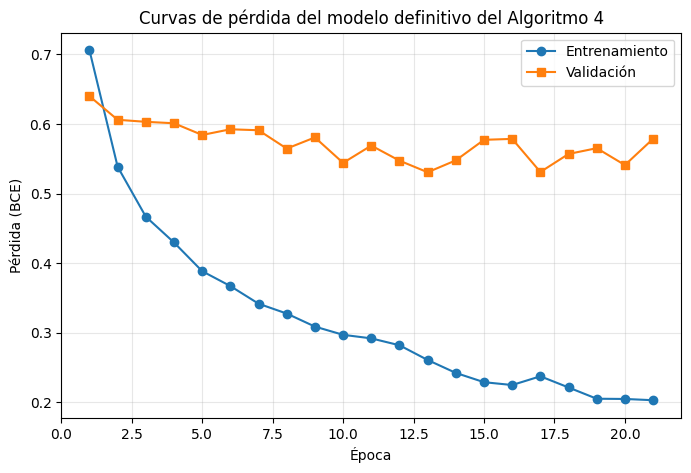

In [ ]:
# Configuración ganadora del grid search multi-seed.
# Tomamos directamente la elegida en la celda multi-seed (cfg_ganadora) para que el
# código y la narrativa nunca puedan divergir. Si por algún motivo no estuviera
# definida, usamos explícitamente la configuración reportada en la memoria.
try:
    cfg_final = dict(cfg_ganadora)
except NameError:
    cfg_final = {
        'hidden_dims':  (128, 32),
        'dropout_rate': 0.5,
        'weight_decay': 1e-4,
        'lr':           1e-3,
        'batch_size':   64,
    }
print(f"Configuración final del Algoritmo 4: {cfg_final}")

# Reset completo de semillas para reproducibilidad
set_all_seeds(SEED)

modelo_final = HybridRecommenderNN(
    input_dim=770,
    hidden_dims=cfg_final['hidden_dims'],
    dropout_rate=cfg_final['dropout_rate'],
)

g_final = torch.Generator(); g_final.manual_seed(SEED)
train_loader_final = DataLoader(train_dataset, batch_size=cfg_final['batch_size'], shuffle=True,  generator=g_final)
val_loader_final   = DataLoader(val_dataset,   batch_size=cfg_final['batch_size'], shuffle=False)

modelo_final, tr_losses_final, va_losses_final = train_model(
    modelo_final, train_loader_final, val_loader_final,
    epochs=50, lr=cfg_final['lr'], weight_decay=cfg_final['weight_decay'],
    patience=8, device=device, verbose=True,
)

# Curvas finales
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(tr_losses_final) + 1), tr_losses_final, label='Entrenamiento', marker='o')
plt.plot(range(1, len(va_losses_final) + 1), va_losses_final, label='Validación',    marker='s')
plt.xlabel('Época'); plt.ylabel('Pérdida (BCE)')
plt.title('Curvas de pérdida del modelo definitivo del Algoritmo 4')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### **Evaluación final sobre `df_test`**

Aplicamos el modelo definitivo sobre el conjunto de prueba, que ha
permanecido oculto durante todas las fases anteriores (entrenamiento,
validación interna, grid search y multi-seed). Las métricas obtenidas
constituyen el rendimiento final reportado del Algoritmo 4.

In [ ]:
resultados_alg4_final = {'recall': [], 'ndcg': [], 'diversity': []}

print(f"Evaluación final del Algoritmo 4 sobre {len(usuarios_test)} usuarios de test...")

for user in tqdm(usuarios_test):
    true_texts = (df_test[df_test['username'] == user]['message_text;']
                          .dropna().drop_duplicates().tolist())
    if not true_texts:
        continue

    recs = get_neural_recommendations(user, df_train, df_messages,
                                      modelo_final, build_feature_vector, top_k=10)
    if not recs:
        continue

    rec_texts = [rec['content'] for rec in recs]
    resultados_alg4_final['recall'].append(   calculate_recall(rec_texts, true_texts, k=10))
    resultados_alg4_final['ndcg'].append(     calculate_ndcg(rec_texts,   true_texts, k=10))
    resultados_alg4_final['diversity'].append(calculate_diversity(rec_texts, model, embedding_map=embedding_map))

print("\n" + "="*60)
print("  RESULTADOS FINALES DEL ALGORITMO 4 (modelo óptimo)")
print("="*60)
print(f"  - Recall@10:           {np.mean(resultados_alg4_final['recall']):.4f}")
print(f"  - NDCG@10:             {np.mean(resultados_alg4_final['ndcg']):.4f}")
print(f"  - Diversidad temática: {np.mean(resultados_alg4_final['diversity']):.4f}")
print(f"  - Usuarios evaluados:  {len(resultados_alg4_final['recall'])}")

Evaluación final del Algoritmo 4 sobre 219 usuarios de test...


100%|██████████| 219/219 [00:15<00:00, 14.27it/s]


  RESULTADOS FINALES DEL ALGORITMO 4 (modelo óptimo)
  - Recall@10:           0.1181
  - NDCG@10:             0.0845
  - Diversidad temática: 0.8425
  - Usuarios evaluados:  219


## **Ejemplo concreto por algoritmo**

Eligimos un usuario con histórico diverso (mensajes de 3-4 temáticas distintas) para que los ejemplos sean ilustrativos. Por ejemplo `william_fe3e1e_746`, que también tiene más de 6 interacciones en df_train y autores variados.

In [ ]:
ejemplo_user = 'william_fe3e1e_746'  # mejor con ≥6 interacciones y temáticas diversas

# Algoritmo 4
print(f"\n--- Algoritmo 4, Top-5 para {ejemplo_user} ---")
for rank, r in enumerate(get_neural_recommendations(
        ejemplo_user, df_train, df_messages, modelo_final, build_feature_vector, top_k=5), 1):
    print(f"  {rank}. [score={r['score']:.3f}] {r['author']}: {r['content'][:60]}...")


--- Algoritmo 4, Top-5 para william_fe3e1e_746 ---
  1. [score=0.919] dee22e_wnzine_dee22e: it's just so heartbreaking seeing everything happening in uk...
  2. [score=0.913] margaret_idr872_176010884: trucking across the country, you see so many cultures. it's ...
  3. [score=0.889] fe30d1_keoisa_fe30d1: it's definitely a mess. 'peace always wins' is a nice though...
  4. [score=0.825] juan_238f22_836: summited at sunrise this morning. 5am alarm, frozen fingers,...
  5. [score=0.800] car9895_nwz_bc398f: trail dust in my shoes, sun on my neck, no signal anywhere. ...
